In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df= pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [ ]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [ ]:
df.shape

(37249, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [ ]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [ ]:
df[df['clean_comment'].isnull()]['category'].value_counts()


,count
category,
0,100


In [ ]:
# can see that 0 category has 100 values missing



In [ ]:
df.dropna(inplace= True)

In [ ]:
df.isnull().sum()


,0
clean_comment,0
category,0


In [ ]:
df.duplicated().sum()

np.int64(350)

In [ ]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [ ]:
df.drop_duplicates(inplace= True)

In [ ]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [ ]:
df = df[df['clean_comment'].str.strip() != '']


In [ ]:
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [ ]:
df['clean_comment']=df['clean_comment'].str.lower()

In [ ]:
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [ ]:
df['clean_comment'] = df['clean_comment'].str.strip()
df[df['clean_comment'].str.startswith(' ') | df['clean_comment'].str.endswith(' ')]


,clean_comment,category


In [ ]:
df[df['clean_comment'].str.contains(r'http|www\.', case=False, na=False)]


,clean_comment,category
761,alliance result leads change total bjp aap con...,0
1790,did your work involve actively whitewashing na...,-1
2471,yeshasvini http www yeshasvini kar nic scheme ...,-1
5150,check out privacytools https www privacytools ...,0
5182,aurangzeb discriminatory policies ece some aur...,1
5186,good job giving them traffic dumbass next time...,1
6755,here png one from new years day here the full ...,-1
9102,heartbreaking picture hillary with group child...,1
9785,this ama being permanently archived the winnow...,1
10234,government marketplace https gem gov since the...,-1


In [ ]:
df[df['clean_comment'].str.contains(r'\n', na=False)]


,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1
...,...,...
35128,火箭o辛基 2016 sughosh bansal mission “make india”...,-1
35230,yikes the title should blind bhakts modi hater...,1
36187,hahahahahhahahah \niska klpd hogya,0
36517,्ा् ी ाी े ो ेी ाी े।\nे ी,0


In [ ]:
df['clean_comment'] = df['clean_comment'].str.replace(r'\n', ' ', regex=True)


In [ ]:
## EDA

In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df['word_count'] = df['clean_comment'].str.split().str.len()


In [ ]:
df

,clean_comment,category,word_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112
...,...,...,...
37244,jesus,0,1
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19
37246,downvote karna tha par upvote hogaya,0,6
37247,haha nice,1,2


In [ ]:
df['word_count'].describe()

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


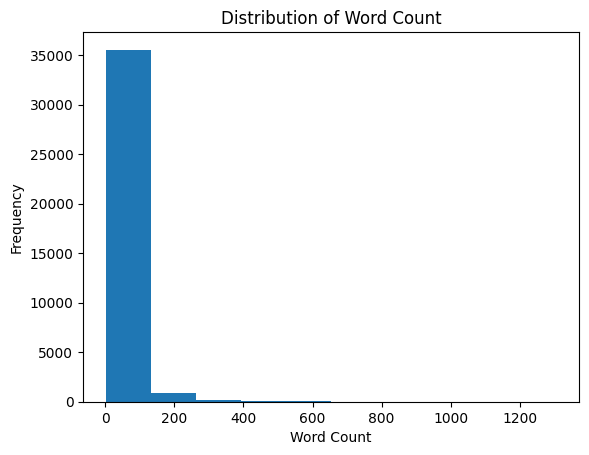

In [ ]:
plt.figure()
plt.hist(df['word_count'])
plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

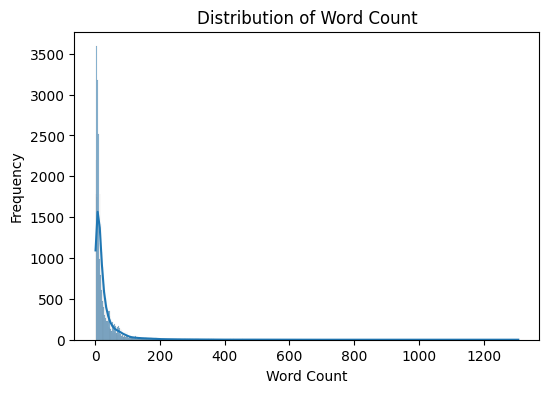

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df['word_count'], kde=True)
plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


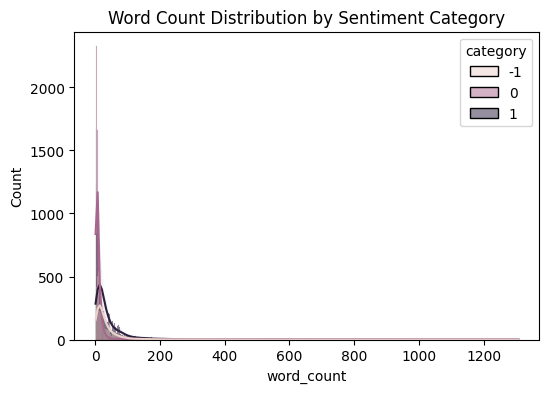

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='word_count', hue='category', kde=True)
plt.title("Word Count Distribution by Sentiment Category")
plt.show()


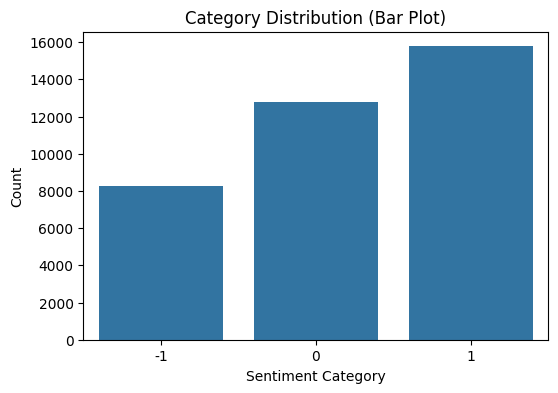

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='category', data=df)
plt.title("Category Distribution (Bar Plot)")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.show()


In [ ]:
pip install nltk

In [ ]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['stopword_count'] = df['clean_comment'].apply(
    lambda x: sum(1 for word in x.split() if word.lower() in stop_words)
)


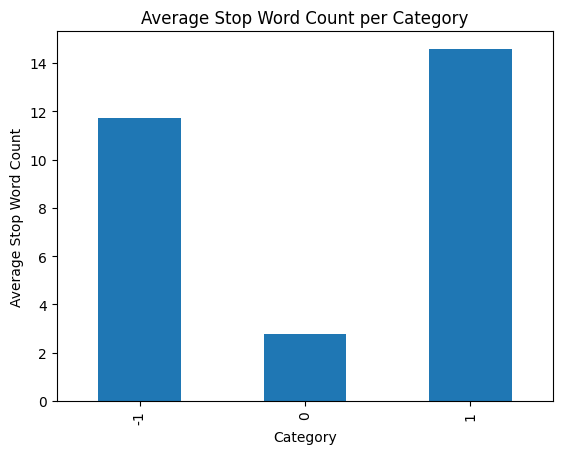

In [ ]:
import matplotlib.pyplot as plt

df.groupby('category')['stopword_count'].mean().plot(kind='bar')
plt.title("Average Stop Word Count per Category")
plt.xlabel("Category")
plt.ylabel("Average Stop Word Count")
plt.show()


In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Extract only stop words from all comments
all_stopwords = df['clean_comment'].apply(
    lambda x: [word.lower() for word in x.split() if word.lower() in stop_words]
)

# Flatten the list
all_stopwords = [word for sublist in all_stopwords for word in sublist]

# Get top 25 most common stop words
top_25_stopwords = pd.Series(all_stopwords).value_counts().head(25)

top_25_stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,count
the,57669
and,28950
that,15372
this,13463
for,12976
you,11723
are,10566
not,8691
they,8654
have,8380


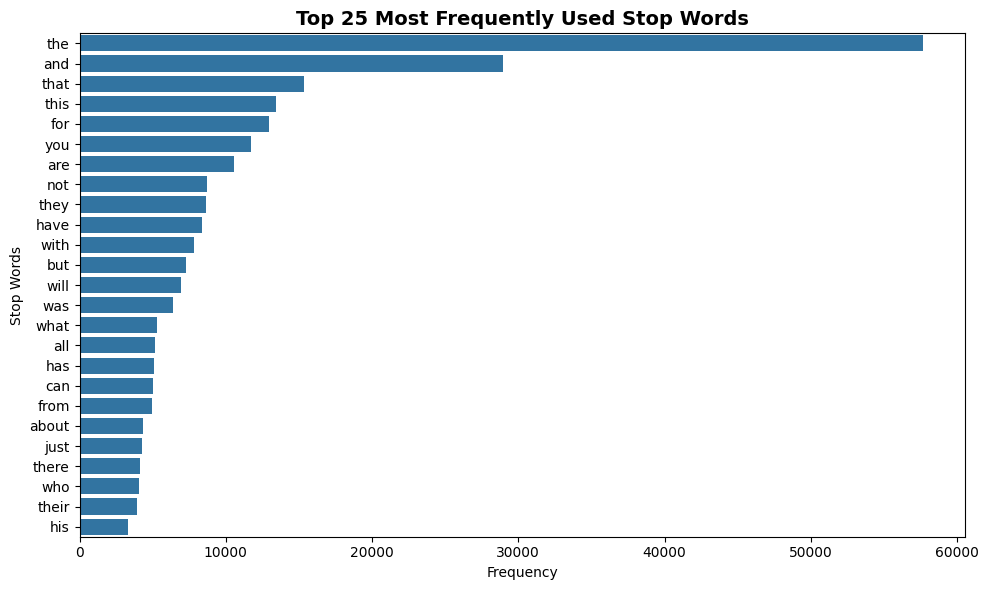

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_25_stopwords.values,
    y=top_25_stopwords.index
)

plt.title("Top 25 Most Frequently Used Stop Words", fontsize=14, fontweight='bold')
plt.xlabel("Frequency")
plt.ylabel("Stop Words")
plt.tight_layout()
plt.show()


In [ ]:
import string

df['punctuation_count'] = df['clean_comment'].apply(
    lambda x: sum(1 for char in x if char in string.punctuation)
)


In [ ]:
df

,clean_comment,category,word_count,stopword_count,punctuation_count
0,family mormon have never tried explain them th...,1,39,13,0
1,buddhism has very much lot compatible with chr...,1,196,59,0
2,seriously don say thing first all they won get...,-1,86,40,0
3,what you have learned yours and only yours wha...,0,29,15,0
4,for your own benefit you may want read living ...,1,112,45,0
...,...,...,...,...,...
37244,jesus,0,1,0,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,0
37246,downvote karna tha par upvote hogaya,0,6,0,0
37247,haha nice,1,2,0,0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Create Bigram Vectorizer
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')

# Fit & Transform
bigram_matrix = bigram_vectorizer.fit_transform(df['clean_comment'])

# Convert to DataFrame
bigram_df = pd.DataFrame(
    bigram_matrix.toarray(),
    columns=bigram_vectorizer.get_feature_names_out()
)

# Get Top 25 Bigrams
top_25_bigrams = bigram_df.sum().sort_values(ascending=False).head(25)

top_25_bigrams


,0
free encyclopedia,623
encyclopedia team,598
good good,409
prime minister,389
best overall,375
don know,352
looks like,339
don think,334
team reached,322
social media,316


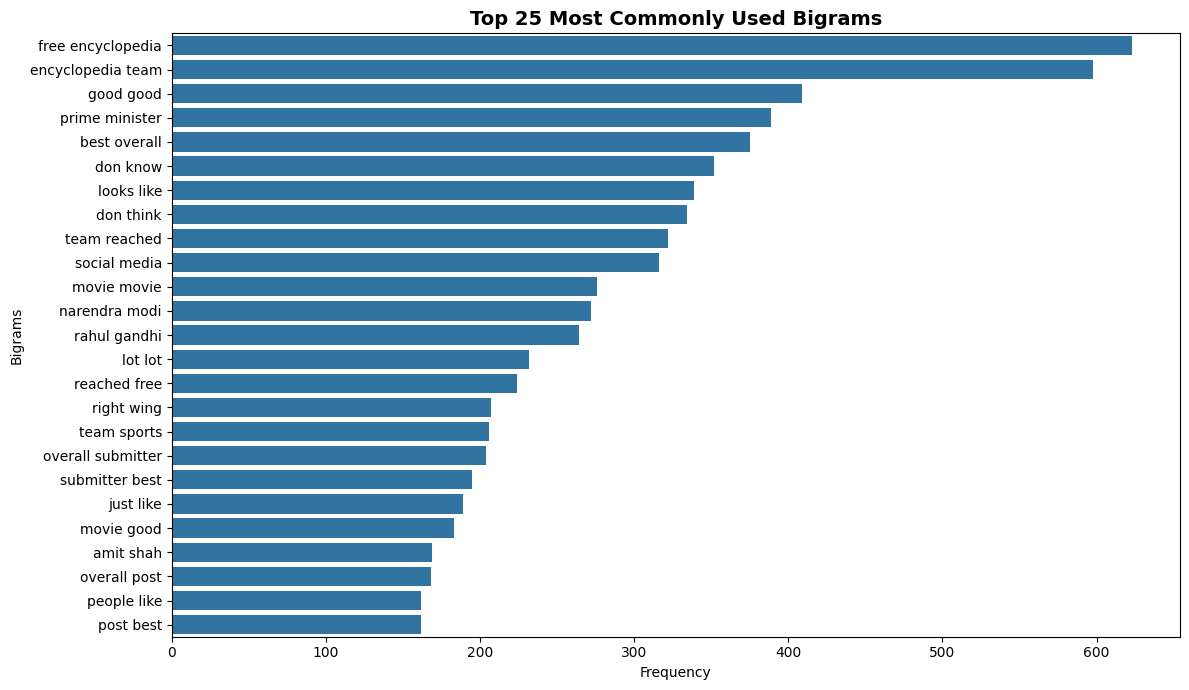

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.barplot(
    x=top_25_bigrams.values,
    y=top_25_bigrams.index
)

plt.title("Top 25 Most Commonly Used Bigrams", fontsize=14, fontweight='bold')
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Create Trigram Vectorizer
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english')

# Fit & Transform
trigram_matrix = trigram_vectorizer.fit_transform(df['clean_comment'])

# Convert to DataFrame
trigram_df = pd.DataFrame(
    trigram_matrix.toarray(),
    columns=trigram_vectorizer.get_feature_names_out()
)

# Get Top 25 Trigrams
top_25_trigrams = trigram_df.sum().sort_values(ascending=False).head(25)

top_25_trigrams


,0
free encyclopedia team,598
good good good,385
encyclopedia team reached,316
movie movie movie,266
team reached free,224
reached free encyclopedia,223
lot lot lot,214
best overall submitter,204
overall submitter best,195
submitter best overall,194


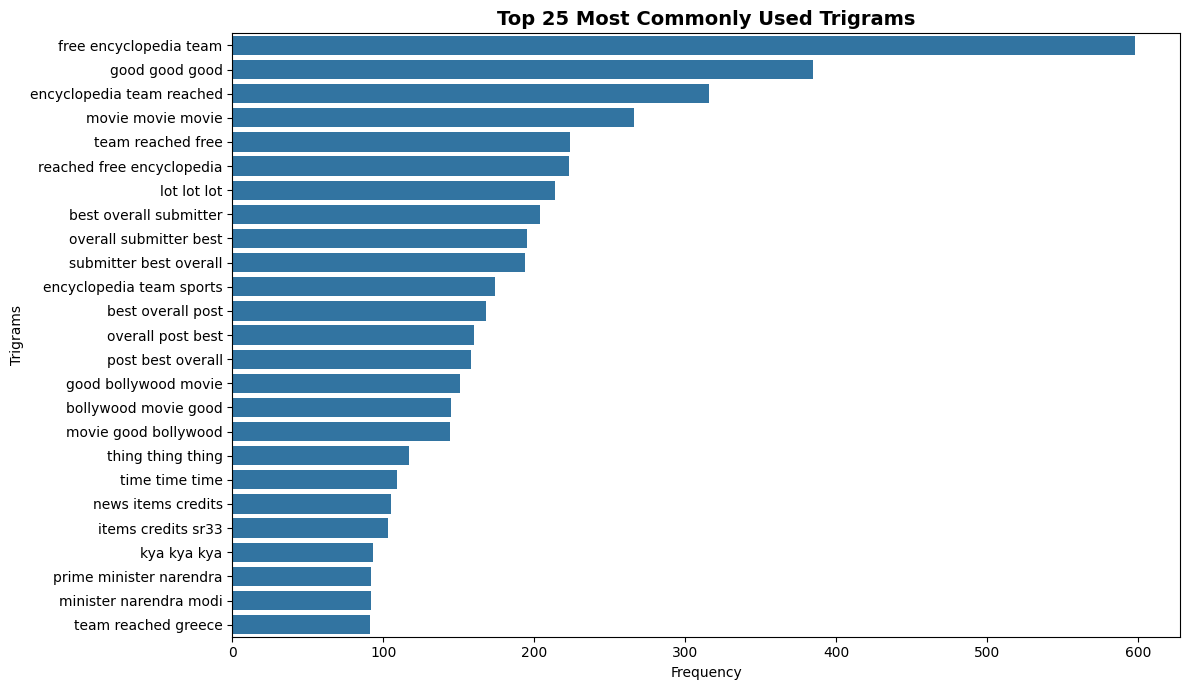

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.barplot(
    x=top_25_trigrams.values,
    y=top_25_trigrams.index
)

plt.title("Top 25 Most Commonly Used Trigrams", fontsize=14, fontweight='bold')
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.tight_layout()
plt.show()


In [ ]:
import re

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: re.sub(r"[^a-zA-Z.,!?'\"]", " ", str(x))
)

# Remove extra spaces created after cleaning
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())


In [ ]:
from nltk.corpus import stopwords

# Keep important negation words for sentiment
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Create new column instead of overwriting
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)


In [ ]:
df.sample(5)

,clean_comment,category,word_count,stopword_count,punctuation_count,no_stopwords_comment
17979,think ipl contract briefcases arrived dressing...,0,10,3,0,think ipl contract briefcases arrived dressing...
33128,modi rahul idiots fuck,-1,8,4,0,modi rahul idiots fuck
13440,but bitch tits fit blouse,1,8,4,0,but bitch tits fit blouse
35643,come not much thread calling modi fans please ...,-1,17,7,0,come not much thread calling modi fans please ...
27459,restricted area,0,5,3,0,restricted area


In [ ]:
df = df.drop(columns=['no_stopwords_comment'])


In [ ]:
df

,clean_comment,category,word_count,stopword_count,punctuation_count
0,family mormon never tried explain still stare ...,1,39,13,0
1,buddhism much lot compatible christianity espe...,1,196,59,0
2,seriously say thing first get complex explain ...,-1,86,40,0
3,learned want teach different focus goal not wr...,0,29,15,0
4,benefit may want read living buddha living chr...,1,112,45,0
...,...,...,...,...,...
37244,jesus,0,1,0,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,0
37246,downvote karna tha par upvote hogaya,0,6,0,0
37247,haha nice,1,2,0,0


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join(lemmatizer.lemmatize(word) for word in x.split())
)


In [ ]:
df

,clean_comment,category,word_count,stopword_count,punctuation_count
0,family mormon never tried explain still stare ...,1,39,13,0
1,buddhism much lot compatible christianity espe...,1,196,59,0
2,seriously say thing first get complex explain ...,-1,86,40,0
3,learned want teach different focus goal not wr...,0,29,15,0
4,benefit may want read living buddha living chr...,1,112,45,0
...,...,...,...,...,...
37244,jesus,0,1,0,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,0
37246,downvote karna tha par upvote hogaya,0,6,0,0
37247,haha nice,1,2,0,0
